# 06. On-field player ratings (M5b)

**License: this notebook's outputs are CC BY-SA 4.0.** They are derived from nflverse participation data: NFL Next Gen Stats via nflverse (2016-2022) and FTN Data via nflverse (2023+). Nothing here feeds A4s or any CC BY artifact.

M5 rated players from box scores, which can't see most of what most players do (notebook 05). M5b rates them from **who was on the field for every snap**: regularized adjusted plus-minus (RAPM), with priors. The method is `context/ml-m5b-method.md`; the results are in `context/ml.md` ("M5b build notes").

1. RAPM from first principles, on two players.
2. The data: 22 players on every play.
3. The real ratings, with intervals.
4. Does it predict? The season-ahead test on 2018 and 2019.
5. What the test can't tell us yet.

It reads files saved by `scripts/ml_m5b.py` (`clean`, `tune`, `dev`, `leakcheck`) in `data/raw/ml/m5b/` and the run records in `experiments/runs/`. Nothing here touches the 2020-2025 holdout.

In [1]:
import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nflelo.ml import data as D, registry
from nflelo.ml.players import rapm

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 160)
INK, ACCENT, MUTED, BAD, MODEL = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b", "#7b4fc9"

M5B = D.ML_DIR / "m5b"
load = lambda name: json.loads((M5B / name).read_text())  # noqa: E731
cleaning, tuning, dev, leak = load("cleaning.json"), load("tuning.json"), load("dev.json"), load("leakcheck.json")
ratings = pd.read_parquet(M5B / "ratings_through_2019.parquet")
runs = {r["name"]: r for r in registry.load_runs() if r["name"].startswith("m5b_dev")}
print(cleaning["note"])

CC BY-SA 4.0. Derived from nflverse participation data: NFL Next Gen Stats via nflverse (2016-2022), FTN Data via nflverse (2023+).


## 1. RAPM from first principles

Every play gives one equation: the play's EPA equals a baseline, plus the effect of each offensive player on the field, plus the effect of each defender, plus noise. Solve all the equations together and each player's effect is what's left after accounting for everyone he played with and against.

The catch is **collinearity**. Take two offensive linemen, A and B, who are always on the field together. The data can measure their *combined* effect, but nothing in the data says how to split it. Ordinary least squares has infinitely many answers.

A small simulation: 20,000 plays, A is truly worth +0.10 EPA per play, B is worth 0, and EPA noise is about as large as in real football (SD 1.4). Half the plays have both on the field, the other half neither. The ridge strength is 1,000 plays.

In [2]:
rng = np.random.default_rng(0)
n, true = 20000, np.array([0.10, 0.0])

def simulate(apart_share):
    on = rng.uniform(size=n) < 0.5
    a, b = on.copy(), on.copy()
    split = rng.uniform(size=n) < apart_share          # on some plays only one of them plays
    b[split & on] = False
    a[split & ~on] = True
    X = np.column_stack([a, b]).astype(float)
    y = X @ true + rng.normal(0, 1.4, n)
    return X - X.mean(axis=0), y - y.mean()

def ridge(X, y, lam, prior):
    # minimize |y - X beta|^2 + lam * |beta - prior|^2
    return np.linalg.solve(X.T @ X + lam * np.eye(2), X.T @ y + lam * np.asarray(prior))

X, y = simulate(apart_share=0.0)
print("Rank of X'X when they always play together:", np.linalg.matrix_rank(X.T @ X), "(2 would be solvable)")
rows = {
    "ridge toward 0": ridge(X, y, 1000, [0, 0]),
    "ridge toward a prior (A 0.10, B 0)": ridge(X, y, 1000, [0.10, 0.0]),
    "ridge toward a wrong prior (A 0, B 0.10)": ridge(X, y, 1000, [0.0, 0.10]),
}
X2, y2 = simulate(apart_share=0.5)
rows["apart on half the plays, ridge toward 0"] = ridge(X2, y2, 1000, [0, 0])
t = pd.DataFrame(rows, index=["A", "B"]).T
t["A + B"] = t.sum(axis=1)
t.round(3)

Rank of X'X when they always play together: 1 (2 would be solvable)


,A,B,A + B
ridge toward 0,0.045,0.045,0.089
"ridge toward a prior (A 0.10, B 0)",0.099,-0.001,0.098
"ridge toward a wrong prior (A 0, B 0.10)",-0.001,0.099,0.098
"apart on half the plays, ridge toward 0",0.079,-0.004,0.075


How to read it:

- **Ridge toward zero** (classic RAPM) gives A and B the same value: it splits the pair's effect evenly, because nothing in the data says otherwise.
- **Ridge toward a prior** splits it the way the prior says. The data still decide the *sum*; the prior only decides the split. That's why a good prior matters most for linemen, who are almost always on the field together.
- **A wrong prior** puts the effect on the wrong player, with the same sum. A prior is a bet; the intervals below show how much of each rating is that bet.
- **When the two players are apart** on some plays, the data can separate them, even with a prior of zero (with noise this large, only roughly: the interval on each is about plus or minus 0.05).

In M5b the prior for each player is his M5 box-score value (scaled), or replacement level (0) if he has none, and each position group gets its own ridge strength: how far the data may pull a player from his prior. Each season's fit starts from the previous fits, with old seasons' evidence discounted (`decay`).

## 2. The data: 22 players on every play

Participation lists the offensive and defensive players on each play by GSIS ID. On some plays one side lists 10 or 12 IDs (in 2016 a player with no ID mapping; in 2018-2019 an extra ID that wasn't on the play). The full list of 22 players on the play is always there under a different ID, which the players table maps to GSIS. Assigning each of the 22 to his team rebuilds the sides. On plays whose lists were already clean, the rebuild reproduces them exactly, so it only changes plays that would otherwise be dropped.

In [3]:
rep = pd.DataFrame(cleaning["report"]).set_index("season")
rep[["era", "clean_plays", "kept", "repaired", "raw_drop_rate", "drop_rate"]].style.format(
    {"raw_drop_rate": "{:.1%}", "drop_rate": "{:.2%}", "clean_plays": "{:,}", "kept": "{:,}", "repaired": "{:,}"})

,era,clean_plays,kept,repaired,raw_drop_rate,drop_rate
season,,,,,,
2016,ngs,"28,488","28,367","3,511",12.7%,0.42%
2017,ngs,"28,086","28,051",0,0.1%,0.12%
2018,ngs,"27,629","27,611","2,169",7.9%,0.07%
2019,ngs,"27,957","27,932","1,335",4.9%,0.09%
2020,ngs,"28,744","28,715",0,0.1%,0.10%
2021,ngs,"29,557","29,535",0,0.1%,0.07%
2022,ngs,"30,439","30,412",0,0.1%,0.09%
2023,ftn,"30,065","30,040",0,0.1%,0.08%
2024,ftn,"29,513","29,489",0,0.1%,0.08%


Without the repair, 2016 would lose 13% of its plays and 2018 8%. With it, no season loses more than 0.5%. The source changed from Next Gen Stats to FTN in 2023; player counts per season and position stay steady across the switch (`python scripts/ml_m5b.py clean`).

## 3. The ratings, with intervals

These are the ratings fit on 2016-2019 (the ones that would predict 2020), with the settings tuned on the development predictions:

In [4]:
c = tuning["chosen"]
print(f"decay of older seasons {c['decay']}, prior = box value x {c['box_scale']}, situation terms {c['situation']}")
pd.Series(c["lam"], name="ridge strength (plays)").sort_values().to_frame().T

decay of older seasons 1.0, prior = box value x 0.25, situation terms True


,QB,OL,RB,LB,TE,S,WR,CB,DL
ridge strength (plays),500.0,1000.0,1000.0,2000.0,2000.0,4000.0,4000.0,32000.0,1024000.0


Read the ridge strengths as "how many plays of evidence it takes to move halfway from the prior", ignoring collinearity. Quarterbacks move freely (500). Linemen and running backs move after about 1,000 plays, a little more than one season. Cornerbacks barely move (32,000), and defensive linemen not at all: on two seasons of data, the on-field evidence for defensive linemen didn't predict the next season better than their box-score prior, so the tuning left them on it. `decay` 1 means older seasons count fully.

The **value** is EPA per play while the player is on the field, relative to replacement level (+ is good for his team, on offense or defense). Every value has a posterior standard deviation. Here are the top quarterbacks, linemen and linebackers in 2019, with 90% intervals:

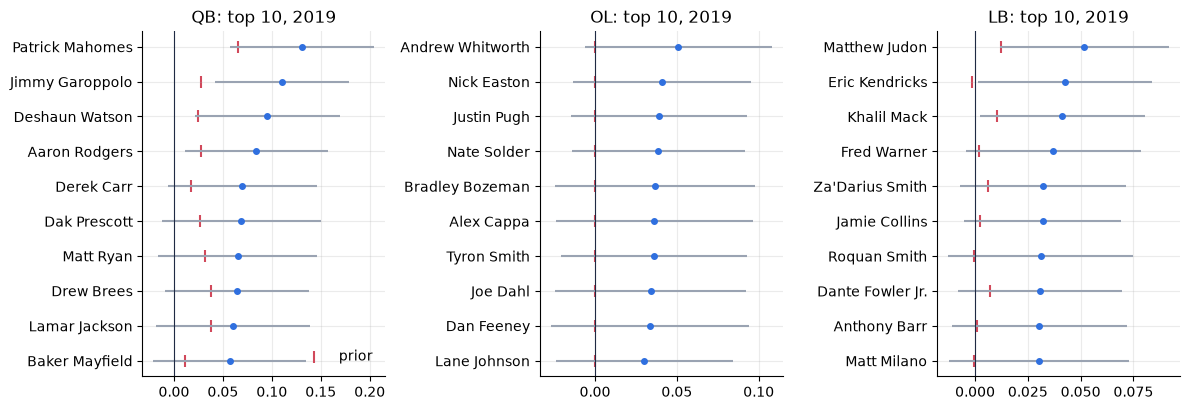

In [5]:
main = ratings[ratings["side_ok"] & ratings["active"] & (ratings["snaps_T"] >= 300)]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, g in zip(axes, ["QB", "OL", "LB"]):
    x = main[main["group"] == g].sort_values("value", ascending=False).head(10).iloc[::-1]
    ax.errorbar(x["value"], np.arange(len(x)), xerr=1.645 * x["sd"], fmt="o", color=ACCENT, ecolor=MUTED, ms=4)
    ax.scatter(x["prior_value"], np.arange(len(x)), marker="|", color=BAD, s=80, label="prior")
    ax.set_yticks(np.arange(len(x)), x["name"])
    ax.axvline(0, color=INK, lw=0.8)
    ax.set_title(f"{g}: top 10, 2019")
axes[0].legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

The names pass a smell test (Mahomes, Garoppolo and Watson lead the quarterbacks; Whitworth leads the linemen; Judon, Kendricks and Mack the linebackers). But look at the intervals: for most players they cross zero. That's the honest picture. One season of snaps can't pin down most individual players, and the ratings say so.

How much did the on-field data move each group away from its prior? `sd_ratio` is the posterior SD over the prior SD: 1 means the data taught us nothing about individuals.

In [6]:
pd.DataFrame(dev["ol_movement"]).set_index("group")[["n", "mean_abs_move", "sd_value", "sd_prior", "sd_ratio"]].round(4)

,n,mean_abs_move,sd_value,sd_prior,sd_ratio
group,,,,,
CB,103,0.0012,0.0020,0.0013,0.9859
DL,144,0.0000,0.0027,0.0027,0.9995
LB,115,0.0145,0.0176,0.0031,0.8124
OL,187,0.0149,0.0185,0.0000,0.8177
QB,34,0.0290,0.0374,0.0144,0.7400
RB,40,0.0198,0.0248,0.0037,0.7873
S,77,0.0075,0.0089,0.0007,0.8942
TE,53,0.0100,0.0129,0.0021,0.8636
WR,103,0.0055,0.0080,0.0029,0.9269


- Linemen have no box score, so their prior is flat (`sd_prior` 0) and everything in their spread comes from the on-field data. They moved as much as any group (0.015 EPA per play on average), but their intervals shrank by only 18%.
- Quarterbacks moved most and are the best measured (`sd_ratio` 0.74).
- Defensive linemen and cornerbacks are their box-score priors (`sd_ratio` about 1).

## 4. Does it predict? The season-ahead test

The realistic use is season-ahead: participation for the current season isn't published until after the Super Bowl. So the test fits ratings on seasons before S and predicts every play of S from the 22 players actually on the field (plus the situation terms). Development seasons: 2018 (from 2016-2017) and 2019 (from 2016-2018).

Baselines, on the same plays:

- **team**: the M3 opponent-adjusted team ratings as of week 1 (offense plus defense of the two teams).
- **box**: M5 box-score values summed over the 22 players, refit on the training seasons.
- **intercept**: the average EPA.

Metric: mean squared error of play EPA. Plays within a game aren't independent, so the intervals resample whole games.

In [7]:
p = dev["pooled"]
rows = []
for m in ["rapm", "team", "box", "intercept"]:
    v = p["vs"].get(m)
    rows.append({"model": m, "MSE": p["mse"][m],
                 "RAPM minus model [95% CI]": "" if v is None else f"{v['diff']:+.5f} [{v['ci_low']:+.5f}, {v['ci_high']:+.5f}]"})
print(f"{p['n_plays']:,} plays in {p['n_games']} games")
pd.DataFrame(rows).set_index("model")

55,543 plays in 534 games


,MSE,RAPM minus model [95% CI]
model,,
rapm,1.938630,
team,1.941359,"-0.00273 [-0.00417, -0.00128]"
box,1.940500,"-0.00187 [-0.00319, -0.00048]"
intercept,1.949142,"-0.01051 [-0.01352, -0.00734]"


RAPM beats the team ratings by 0.0027 and the box values by 0.0019, and both intervals exclude zero. The numbers look tiny because a single play is mostly noise (the variance of play EPA is about 1.95); what matters is that the gap is consistent across 534 games. By season:

In [8]:
rows = []
for S, r in dev["per_season"].items():
    rows.append({"season": S, **{m: r["mse"][m] for m in ["rapm", "team", "box", "intercept"]},
                 "RAPM - team": f"{r['vs']['team']['diff']:+.5f} [{r['vs']['team']['ci_low']:+.5f}, {r['vs']['team']['ci_high']:+.5f}]",
                 "RAPM - box": f"{r['vs']['box']['diff']:+.5f} [{r['vs']['box']['ci_low']:+.5f}, {r['vs']['box']['ci_high']:+.5f}]"})
pd.DataFrame(rows).set_index("season").round(5)

,rapm,team,box,intercept,RAPM - team,RAPM - box
season,,,,,,
2018,1.92938,1.93158,1.93194,1.94384,"-0.00219 [-0.00399, -0.00039]","-0.00256 [-0.00443, -0.00079]"
2019,1.94777,1.95103,1.94896,1.95438,"-0.00326 [-0.00550, -0.00112]","-0.00119 [-0.00316, +0.00076]"


Summed to the game level, each team's EPA per play margin in a game, predicted from the lineups that actually played:

In [9]:
mg = p["margin"]
pd.DataFrame({"MSE": mg["mse"], "RAPM minus model [95% CI]": {
    k: f"{v['diff']:+.4f} [{v['ci_low']:+.4f}, {v['ci_high']:+.4f}]" for k, v in mg["vs"].items()}}).round(5).fillna("")

,MSE,RAPM minus model [95% CI]
rapm,0.17934,
team,0.18629,"-0.0069 [-0.0120, -0.0019]"
box,0.18900,"-0.0097 [-0.0152, -0.0046]"
intercept,0.19298,"-0.0136 [-0.0215, -0.0060]"


This is the case for player ratings: rosters turn over, and only a player rating follows the players. Season-ahead, the team ratings remember last year's roster; the player ratings see this year's.

**Stability.** Do ratings carry from one season to the next? Two versions: the chained ratings (each fit includes all earlier seasons, so consecutive fits share data and must correlate), and single-season fits (one season of data each, on top of the prior), which is the honest test of whether a player's on-field effect repeats.

In [10]:
y = pd.DataFrame(dev["year_to_year"])
t = y.pivot_table(index="group", columns="fit", values="corr", aggfunc="mean").round(2)
t["n per pair"] = y[y["fit"] == "chained"].groupby("group")["n"].mean().round(0).astype(int)
t.rename(columns={"chained": "chained fits", "single-season": "single-season fits"})

fit,chained fits,single-season fits,n per pair
group,,,
CB,0.69,0.45,90
DL,0.63,0.65,130
LB,0.80,0.24,98
OL,0.77,0.10,157
QB,0.85,0.43,28
RB,0.85,0.41,38
S,0.78,0.19,70
TE,0.77,0.09,47
WR,0.77,0.32,90


Averaged over 2016-17, 2017-18 and 2018-19 (players with 200+ snaps in both seasons). Single-season stability is weak: about 0.1 for linemen and tight ends, 0.2 for linebackers and safeties, 0.3 for receivers, and about 0.4 for quarterbacks and running backs. (Defensive linemen and cornerbacks look steadier only because their ratings are mostly their box-score priors.) Most of one season's on-field signal for most players is noise, which is exactly why the ridge pulls so hard and why the chaining across seasons matters.

**The game model (descriptive only).** A4s plus a lineup term built from RAPM values and participation snap shares, on REG 2018-2019 games with moneylines:

In [11]:
gm = runs["m5b_dev_game_model"]["result"]
pd.Series({"games": gm["n"], "A4s Brier": round(gm["brier_a4s"], 4), "A4s + RAPM lineup term": round(gm["brier_new"], 4),
           "difference [95% CI]": f"{gm['vs_a4s']['diff']:+.4f} [{gm['vs_a4s']['ci_low']:+.4f}, {gm['vs_a4s']['ci_high']:+.4f}]",
           "coefficient by season": {k: round(v, 2) for k, v in gm["coef_by_season"].items()},
           "correlation with (market - A4s)": round(gm["corr_market_departure"], 2)}).to_frame("dev")

,dev
games,512
A4s Brier,0.217
A4s + RAPM lineup term,0.2177
difference [95% CI],"+0.0007 [-0.0012, +0.0025]"
coefficient by season,"{'2018': -4.47, '2019': -1.15}"
correlation with (market - A4s),0.2


No gain, and the coefficient (fit on only 2016-2017 games, 512 of them) comes out negative even though the term agrees with the market (+0.20). With so few games this is noise, the same lack of power M5 ran into; the spec says in advance that this test is reported, not used for acceptance.

**Leakage.** The real-data check corrupted everything from 2019 (play-by-play, participation, depth charts, injuries, rosters), rebuilt every input, refit, and predicted the clean 2019 plays:

In [12]:
pd.DataFrame({k: leak[k] for k in ["rapm", "team", "box", "intercept", "positive_control"]}).T

,max_abs_diff,changed,leak_free
rapm,0.0,0,True
team,0.0,0,True
box,0.0,0,True
intercept,0.0,0,True
positive_control,0.76839,27932,False


Every model's 2019 predictions are identical to the last digit; the positive control (which trains on 2019 itself) changes every play, as it must. This check found one real leak during the build: M5's position lookup can borrow a player's position from a later season, which moved the box-score priors. M5b now rebuilds the priors for each season from earlier data only.

## 5. What the test can't tell us yet

- **The development numbers are optimistic.** The ridge strengths, decay and prior scale were tuned on these same 2018-2019 predictions. The baselines were not tuned here.
- **The holdout decides.** 2020-2025, season-ahead, scored once with everything frozen. Acceptance: RAPM beats both baselines on play-level MSE with game-cluster intervals entirely below zero. The protocol is in `context/ml.md`, "M5b holdout pre-registration".
- **Individual ratings are uncertain.** Treat a rating as a range, not a number, especially for linemen and defensive backs.